# 熱圖 Heatmap：把生活表格變成看得懂、說得清楚的圖

## 第一部分：使用 Matplotlib
先手動放刻度、加文字和設色條，理解圖的每一個元素由誰控制；這些觀念也會用在Seaborn。


### 範例：一週三餐，錢都花在哪裡

**資料檔：** [datasets/01_一週三餐花費.csv](datasets/01_一週三餐花費.csv)  
**範例程式：** [examples/01_一週三餐，錢都花在哪裡.py](examples/01_一週三餐，錢都花在哪裡.py)

月底覺得沒買什麼，錢卻少了一截。先不用責怪自己，拿出七天三餐紀錄，找出值得回想的那幾餐。
一格是「某一餐別在某一天的花費」，不是平均，也不是一家店的價格。同一個人連續七天的資料，不能當作全班的消費習慣。

In [1]:
import pandas as pd

df = pd.read_csv("./datasets/一週三餐花費.csv", encoding="utf-8-sig")
df

,餐別,一,二,三,四,五,六,日
0,早餐,45,50,45,60,50,85,70
1,午餐,90,100,85,110,95,180,150
2,晚餐,110,90,120,100,160,250,120


In [3]:
table = df.set_index("餐別")
table

,一,二,三,四,五,六,日
餐別,,,,,,,
早餐,45,50,45,60,50,85,70
午餐,90,100,85,110,95,180,150
晚餐,110,90,120,100,160,250,120


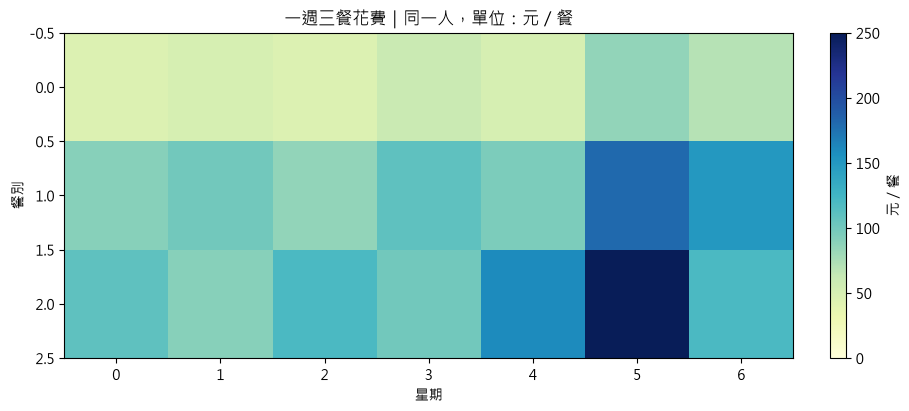

In [9]:
import matplotlib.pyplot as plt

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(9, 4), layout='constrained')

	im = ax.imshow(
		table.to_numpy(), # 將 DataFrame 轉成二維 NumPy 陣列
		cmap="YlGnBu", # 設定熱圖配色：黃 → 綠 → 藍
		vmin=0, # 色彩範圍的最小值
		vmax=250, # 色彩範圍的最大值
		origin="upper", # 第一列從圖表上方開始顯示
		interpolation="nearest", # 不進行顏色平滑，保留每個格子的原始色塊
		aspect="auto" # 自動調整格子的長寬比例，填滿繪圖區域
	)
	
	ax.set(
		title="一週三餐花費｜同一人，單位：元／餐", 
		xlabel="星期",
		ylabel="餐別"
	)
	fig.colorbar(im, ax=ax, label='元／餐')
	plt.show()

### 範例：午休買飯，顏色之外也要讀得出數字

**資料檔：** [datasets/02_午休買飯等多久.csv](datasets/02_午休買飯等多久.csv)  
**範例程式：** [examples/02_午休買飯，顏色之外也要讀得出數字.py](examples/02_午休買飯，顏色之外也要讀得出數字.py)

午休只有一小時，走到店裡才發現排很長，會很懊惱。拿三家店三個時點的單次觀測，練習把等待分鐘直接寫進格子。
這是九次示範觀測，還不是可靠的長期預測；未記錄天氣、點餐內容及店內人力。

In [12]:
import pandas as pd

df = pd.read_csv("./datasets/午休買飯等多久.csv", encoding="utf-8-sig")
table = df.set_index("店家")
table

,11:30,12:00,12:30
店家,,,
便當店,4,12,8
麵店,6,9,5
自助餐,2,7,3


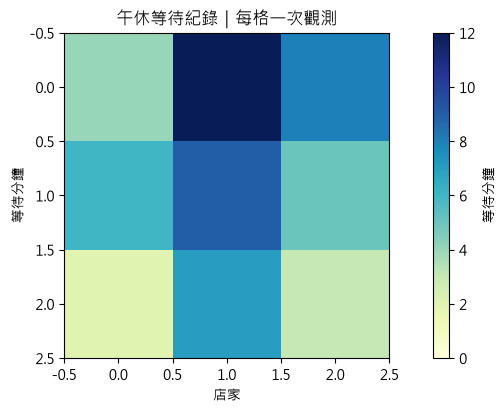

In [13]:
import matplotlib.pyplot as plt

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
	im = ax.imshow(table, cmap='YlGnBu', vmin=0, vmax=12, interpolation='nearest')
	ax.set(
			title="午休等待紀錄｜每格一次觀測", 
			xlabel="店家",
			ylabel="等待分鐘"
		)
	fig.colorbar(im, ax=ax, label='等待分鐘')
	plt.show()

### 範例：六月七月用電，兩張圖要用同一把尺

**資料檔：** [datasets/04_冷氣用電前後.csv](datasets/04_冷氣用電前後.csv)  
**範例程式：** [examples/04_六月七月用電，兩張圖要用同一把尺.py](examples/04_六月七月用電，兩張圖要用同一把尺.py)

七月的圖看起來跟六月一樣深，是否代表用電沒變？若每張圖都自行挑最小值、最大值，答案可能完全相反。這是同戶兩個房間各時段的日平均冷氣用電。

In [ ]:
import pandas as pd

df = pd.read_csv("./datasets/冷氣用電前後.csv", encoding="utf-8-sig")
table = df.set_index("店家")

,月份,房間,上午,下午,晚上
0,六月,客廳,2,5,4
1,六月,臥室,1,3,6
2,七月,客廳,4,8,7
3,七月,臥室,2,6,10


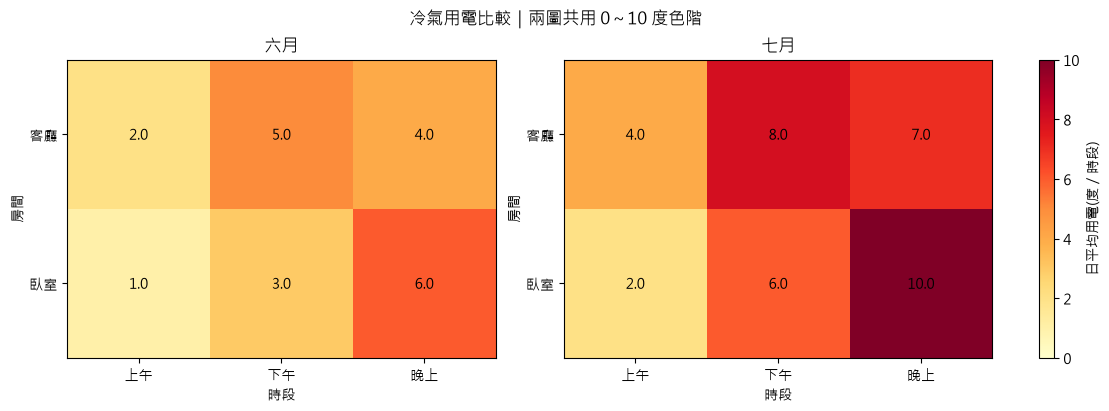

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

### 設定兩張熱圖共用的色彩範圍
norm = Normalize(vmin=0, vmax=10) # 0～10 使用相同色階

### 建立兩張子圖
with plt.style.context("default"):
    # 中文設定
    plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
    plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")

    # 分別繪製六月、七月
    for month, ax in zip(["六月", "七月"], axes):
        table = df.loc[df["月份"] == month].set_index("房間")[["上午", "下午", "晚上"]]

        im = ax.imshow(
            table.to_numpy(), # DataFrame 轉成二維 NumPy 陣列
            cmap="YlOrRd", # 黃 → 橘 → 紅
            norm=norm, # 兩張圖共用 0～10 的色彩範圍
            aspect="auto", # 自動調整格子比例
            interpolation="nearest" # 不進行顏色平滑
        )

        # 設定 X 軸
        ax.set_xticks(
            range(len(table.columns)),
            labels=table.columns
        )

        # 設定 Y 軸
        ax.set_yticks(
            range(len(table.index)),
            labels=table.index
        )

        # 在每個格子顯示數值
        for row in range(len(table.index)):
            for col in range(len(table.columns)):
                ax.text(
                    col,
                    row,
                    f"{table.iloc[row, col]:.1f}",
                    ha="center",
                    va="center"
                )

        ax.set(
            title=month,
            xlabel="時段",
            ylabel="房間"
        )

    # 兩張熱圖共用同一個色條
    fig.colorbar(im, ax=axes, label="日平均用電(度／時段)")

    fig.suptitle("冷氣用電比較｜兩圖共用 0～10 度色階")

    plt.show()

## 這裡開始

## 第二部分：使用 Seaborn 完成10個生活範例

Seaborn建立在Matplotlib之上。它可以自動處理DataFrame標籤、格內數字與部分配色細節，但仍需要你把資料整理成矩陣。這一部分每例都保留 `fig, ax = plt.subplots(...)`，再把 `ax` 傳給 `sns.heatmap`，所以你仍可用Matplotlib改標題、存檔與加文字。

| 想做的事 | Matplotlib常用方式 | Seaborn常用方式 |
|---|---|---|
| 畫規則矩陣 | `ax.imshow(table)` | `sns.heatmap(table, ax=ax)` |
| 寫格內數字 | `ax.text`迴圈 | `annot=True, fmt='.1f'` |
| 放列欄標籤 | 明確設定ticks與labels | DataFrame索引與欄名自動帶入 |
| 留缺值空格 | 遮罩陣列、色盤bad色 | `mask`與畫圖區背景 |
| 多圖比較 | 共用norm或端點 | 各圖明定相同vmin/vmax等設定 |

`sns.heatmap`回傳的是Axes，不是新的原始資料。它不會自動把重複紀錄去掉、不會推測哪個百分比分母才對，也不會因為你使用 `center=0` 就保證色階上下端對稱。需要正負等距的比較時，自己設定例如-1與1，或使用明確的norm。

注意座標差異：imshow中心在整數0、1、2；Seaborn熱圖中心在0.5、1.5、2.5。這是因為Seaborn底層畫網格的邊界從0開始。補字或畫框時，要先確認位置。

### 範例：早餐店的長表，如何變成一張熱圖

**資料檔：** [datasets/11_早餐店長表轉熱圖.csv](datasets/11_早餐店長表轉熱圖.csv)  
**範例程式：** [examples/11_早餐店的長表，如何變成一張熱圖.py](examples/11_早餐店的長表，如何變成一張熱圖.py)


早餐店記錄通常是一列「星期、品項、份數」，不是已經排好的彩色表格。想知道哪天哪種早餐賣得多，要先把這些紀錄放到對應格子。

In [ ]:
import pandas as pd

df = pd.read_csv("./datasets/早餐店長表轉熱圖.csv", encoding="utf-8-sig")
df

,星期,品項,售出份數
0,一,蛋餅,20
1,一,吐司,12
2,一,飯糰,8
3,二,蛋餅,22
4,二,吐司,10
5,二,飯糰,9
6,三,蛋餅,18
7,三,吐司,15
8,三,飯糰,7
9,四,蛋餅,25


In [ ]:
### 把長格式資料攤成表格
table = df.pivot(
    index="品項", # 將「品項」的不同值放到列索引
    columns="星期", # 將「星期」的不同值展開成欄位
    values="售出份數" # 表格中的數值使用「售出份數」
)
### 重新指定列與欄的順序
table = table.reindex(
    index=["蛋餅", "吐司", "飯糰"], # 指定品項的排列順序
    columns=["一", "二", "三", "四", "五"] # 指定星期的排列順序
)

table # 顯示整理完成的樞紐表

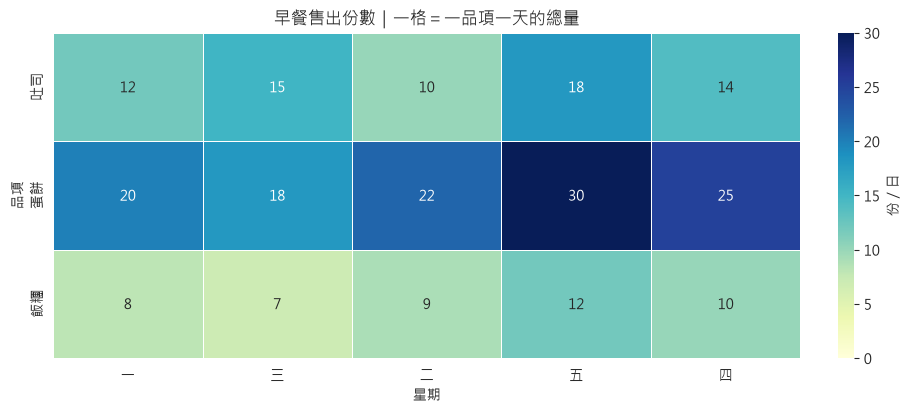

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(9, 4), layout='constrained')
	sns.heatmap(
		table, # 要繪製成熱圖的資料表
		annot=True, # 在每個格子中顯示實際數值
		fmt="d", # 數值以整數格式顯示
		cmap="YlGnBu", # 使用黃→綠→藍的漸層配色
		vmin=0, # 色階的最小值設定為 0
		vmax=30, # 色階的最大值設定為 30
		linewidths=0.5, # 設定每個格子之間的分隔線寬度
		cbar_kws={"label": "份／日"}, # 設定右側色條的標籤
		ax=ax # 指定繪製在哪一個 Axes 上
	)
	ax.set(xlabel='星期', ylabel='品項', title='早餐售出份數｜一格＝一品項一天的總量')

### 範例：等待時間用什麼代表，還要看有幾筆

**資料檔：** [datasets/12_取餐等待中位數.csv](datasets/12_取餐等待中位數.csv)  
**範例程式：** [examples/12_等待時間用什麼代表，還要看有幾筆.py](examples/12_等待時間用什麼代表，還要看有幾筆.py)

兩家店都有午晚餐紀錄，甲店午間有一次等了30分鐘。店家想用一個數字代表平常等待，你會選平均，還是中位數？

In [9]:
import pandas as pd

df = pd.read_csv("./datasets/取餐等待中位數.csv", encoding="utf-8-sig")
df.head()

,店家,時段,等待分鐘
0,甲店,午間,4
1,甲店,午間,5
2,甲店,午間,6
3,甲店,午間,30
4,甲店,晚間,3


In [10]:
table = df.pivot_table(
    index="店家", # 將「店家」放到列索引
    columns="時段", # 將「時段」展開成欄位
    values="等待分鐘", # 要統計的數值欄位
    aggfunc="median" # 計算每間店各時段的等待時間中位數
).reindex(
    index=["甲店", "乙店"], # 指定店家的排列順序
    columns=["午間", "晚間"] # 指定時段的排列順序
)

counts = df.pivot_table(
    index="店家", # 將「店家」放到列索引
    columns="時段", # 將「時段」展開成欄位
    values="等待分鐘", # 要計算筆數的欄位
    aggfunc="count" # 計算每間店各時段有幾筆等待時間資料
).reindex_like(table) # 將列與欄的排列方式調整成與 table 相同
counts

時段,午間,晚間
店家,,
甲店,4,3
乙店,3,2


In [11]:
### 幫熱圖的每一格製作自訂文字標籤
import numpy as np

labels = np.empty(table.shape, dtype=object)
for r, c in np.ndindex(table.shape):
    labels[r,c] = f'{table.iloc[r,c]:.1f}分\nn={counts.iloc[r,c]}'

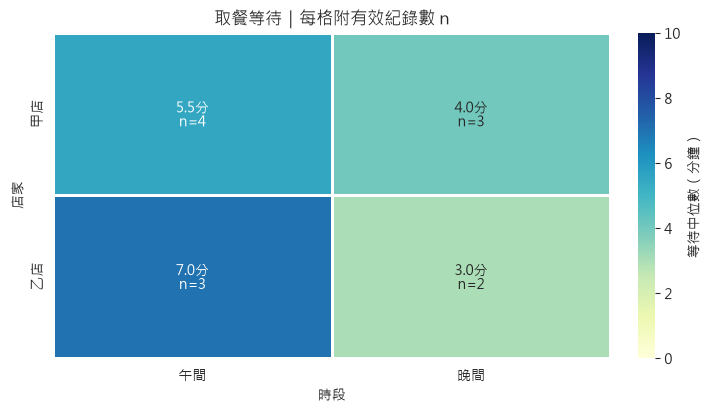

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(7, 4), layout='constrained')
	sns.heatmap(table, annot=labels, fmt='', cmap='YlGnBu', vmin=0, vmax=10,
				linewidths=1, cbar_kws={'label':'等待中位數（分鐘）'}, ax=ax)
	ax.set_title('取餐等待｜每格附有效紀錄數 n')


### 範例：支付次數多，不代表偏好比例高

**資料檔：** [datasets/13_支付方式看比例.csv](datasets/13_支付方式看比例.csv)  
**範例程式：** [examples/13_支付次數多，不代表偏好比例高.py](examples/13_支付次數多，不代表偏好比例高.py)



甲店一天20筆交易，乙店10筆。甲店行動支付有6筆，乙店只有4筆，能不能說甲店顧客比較偏好行動支付？先把分母補進來。

In [14]:
import pandas as pd

df = pd.read_csv("./datasets/支付方式看比例.csv", encoding="utf-8-sig")
df.head()

,交易編號,店家,支付方式
0,T001,甲店,現金
1,T002,甲店,現金
2,T003,甲店,現金
3,T004,甲店,現金
4,T005,甲店,現金


In [15]:
counts = pd.crosstab(df['店家'], df['支付方式']).reindex(index=['甲店','乙店'], columns=['現金','行動支付','信用卡'], fill_value=0)
shares = counts.div(counts.sum(axis=1).replace(0,np.nan), axis=0)

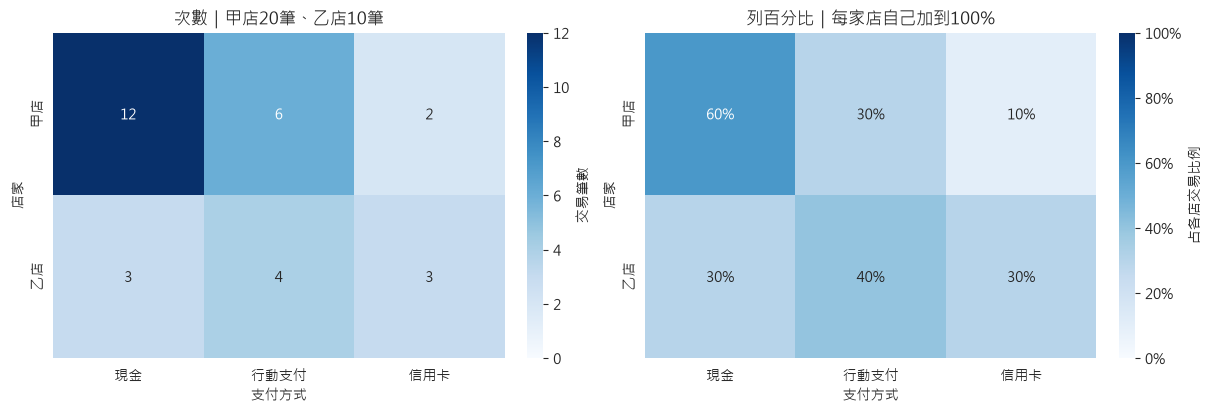

In [17]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
	sns.heatmap(counts, annot=True, fmt='d', cmap='Blues', vmin=0, vmax=12, ax=axes[0], cbar_kws={'label':'交易筆數'})
	sns.heatmap(shares, annot=True, fmt='.0%', cmap='Blues', vmin=0, vmax=1, ax=axes[1], cbar_kws={'label':'占各店交易比例','format':PercentFormatter(1)})
	axes[0].set_title('次數｜甲店20筆、乙店10筆')
	axes[1].set_title('列百分比｜每家店自己加到100%')


### 範例：每台家電自己的高峰，與誰最耗電是兩回事

**資料檔：** [datasets/17_家電自己的高低峰.csv](datasets/17_家電自己的高低峰.csv)  
**範例程式：** [examples/17_每台家電自己的高峰，與誰最耗電是兩回事.py](examples/17_每台家電自己的高峰，與誰最耗電是兩回事.py)


冷氣的數字遠大於電風扇，原始用電圖幾乎只看得到冷氣。若問題是「各台家電哪個月份比自己平常高」，可以先做列標準化。

In [ ]:
import pandas as pd

df = pd.read_csv("./datasets/家電自己的高低峰.csv", encoding="utf-8-sig")
df = df.set_index("家電") # 將「家電」設為索引，剩下的欄位都是數值
row_mean = df.mean(axis=1) # 橫向計算每個家電各月份的平均值
row_sd = df.std(axis=1, ddof=0) # 橫向計算每個家電各月份的母體標準差
z = df.sub(row_mean, axis=0).div(
    row_sd.replace(0, np.nan), # 將標準差為 0 的資料改成 NaN，避免除以 0
    axis=0
) # 每格計算 Z-score：(當月數值 - 該家電平均值) ÷ 該家電標準差


,四月,五月,六月,七月,八月,九月
家電,,,,,,
冰箱,-1.224745,0.000000,-1.224745,1.224745,0.000000,1.224745
冷氣,-1.388730,-0.925820,-0.462910,0.925820,1.388730,0.462910
電風扇,-1.206045,-1.206045,-0.301511,0.603023,1.507557,0.603023
玄關照明,NaN,NaN,NaN,NaN,NaN,NaN


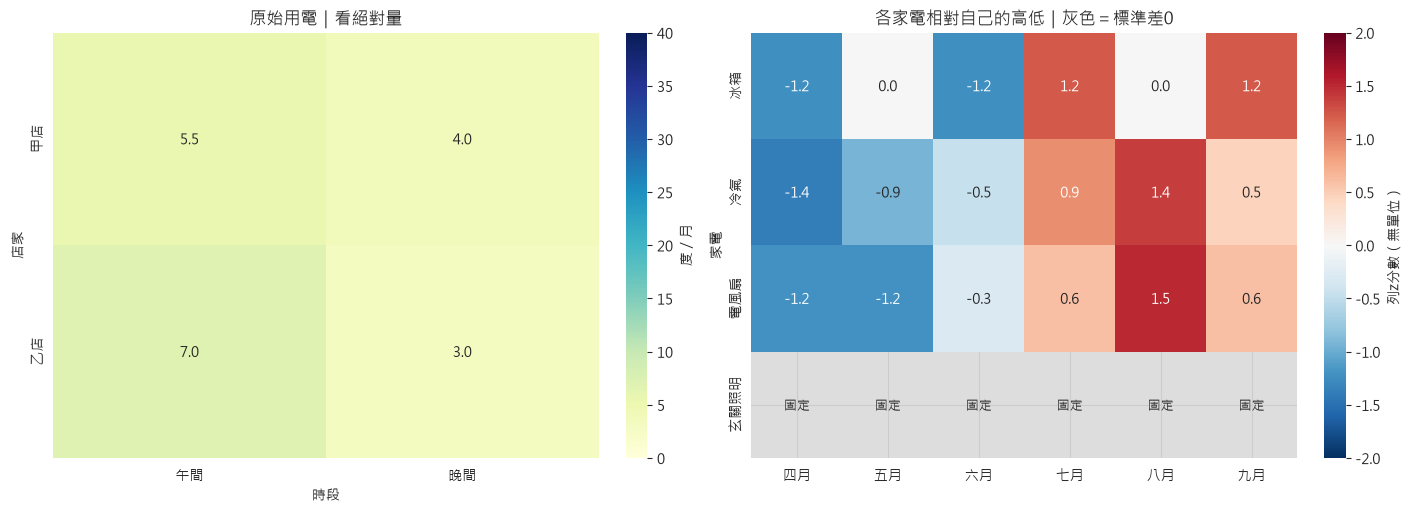

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, axes = plt.subplots(1, 2, figsize=(14, 5), layout='constrained')
	sns.heatmap(table, annot=True, fmt='.1f', cmap='YlGnBu', vmin=0, vmax=40, ax=axes[0], cbar_kws={'label':'度／月'})
	axes[0].set_title('原始用電｜看絕對量')
	axes[1].set_facecolor('#dddddd')
	sns.heatmap(z, annot=True, fmt='.1f', cmap='RdBu_r', vmin=-2, vmax=2, ax=axes[1], cbar_kws={'label':'列z分數（無單位）'})
	for r in np.flatnonzero(row_sd.to_numpy()==0):
		for c in range(z.shape[1]):
			axes[1].text(c+.5,r+.5,'固定',ha='center',va='center',fontsize=9)
	axes[1].set_title('各家電相對自己的高低｜灰色＝標準差0')